# IAM - Avaliação 02
**Disciplina:** Introdução ao Aprendizado de Máquina (ENGG67)  
**Professor:** Antônio C. L. Fernandes Jr.  
**Aluno(s):** Giovane Santos de Santana, Heverton Silva dos Reis  
**Data de Entrega:** 17/06/2025

---

## Introdução


Pesquisadores da universidade de Wisconsin utilizaram técnicas de processamento de imagem e aprendizado de máquina para aumentar a eficiência de um exame para diagnosticar câncer de mama. Neste trabalho será estudado o conjunto de dados utilizado para esse projeto.

---

Antes de começar a análise, é preciso instalar todas as bibliotecas que serão utilizadas:

In [6]:
pip install ucimlrepo

In [7]:
pip install seaborn

In [8]:
pip install scikit-learn==1.7.0

Em seguida, é preciso carregar o dataset, através de importação direta, como indicado pela documentação do repositório:

In [9]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
df = breast_cancer_wisconsin_diagnostic.data.features
dt = breast_cancer_wisconsin_diagnostic.data.targets

Por fim, realiza-se a importação das bibliotecas que serão utilizadas ao longo da análise:

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay

from sklearn.model_selection import cross_validate

from imblearn.over_sampling import SMOTE

---
## Pré-Processamento

### Transformação

Como o dataset é populado por diversos **atributos preditivos** de dimensões e significados diferentes, busca-se realizar uma normalização por amplitude, a **padronização**, visando manter todos os atributos na mesma escala, garantindo que nenhum deles tenha dominância frente aos demais.

In [11]:
scaler = StandardScaler()
atributos_escalados = scaler.fit_transform(df)
df_atributos_escalados = pd.DataFrame(atributos_escalados,columns = df.columns)
df_atributos_escalados

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.110995,0.721473,2.060786,2.343856,1.041842,0.219060,1.947285,2.320965,-0.312589,-0.931027,...,1.901185,0.117700,1.752563,2.015301,0.378365,-0.273318,0.664512,1.629151,-1.360158,-0.709091
565,1.704854,2.085134,1.615931,1.723842,0.102458,-0.017833,0.693043,1.263669,-0.217664,-1.058611,...,1.536720,2.047399,1.421940,1.494959,-0.691230,-0.394820,0.236573,0.733827,-0.531855,-0.973978
566,0.702284,2.045574,0.672676,0.577953,-0.840484,-0.038680,0.046588,0.105777,-0.809117,-0.895587,...,0.561361,1.374854,0.579001,0.427906,-0.809587,0.350735,0.326767,0.414069,-1.104549,-0.318409
567,1.838341,2.336457,1.982524,1.735218,1.525767,3.272144,3.296944,2.658866,2.137194,1.043695,...,1.961239,2.237926,2.303601,1.653171,1.430427,3.904848,3.197605,2.289985,1.919083,2.219635



### Determinando variáveis indicadoras (dummies)

Dado que os **atributos alvo** são do tipo **categórico**, é preciso realizar uma transformação para trabalhar com variáveis do tipo **numérico**, compatíveis com os demais atributos do conjunto de dados, e ideal para trabalhar com o k-NN, que é um método numérico.

In [12]:
dummies = dt.Diagnosis.str.get_dummies()
dummies

,B,M
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1
...,...,...
564,0,1
565,0,1
566,0,1
567,0,1


### Redução de dimensionalidade

Aqui se faz uso do método de Análise de Componentes Principais (**PCA**) buscando reduzir a dimensão do conjunto de dados em análise, que possui cerca de **30 atributos preditivos**. A redução de dimensionalidade visa eliminar redundâncias, já que muitos atributos são fortemente correlacionados, além de diminuir o custo computacional.

Optou-se por escolher a redução que mantivesse até cerca de **95% da variância** original pois permite reduzir a dimensionalidade dos dados preservando a maior parte da informação relevante.

In [13]:
pca = PCA(n_components=0.95)
reducao = pca.fit_transform(df_atributos_escalados)

print(f"Número de componentes: {reducao.shape[1]}")
print(f"Variância explicada por componente: {pca.explained_variance_ratio_}")
print(f"Soma da variância explicada: {sum(pca.explained_variance_ratio_)*100:.2f}%")


Número de componentes: 10
Variância explicada por componente: [0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734 0.01588724 0.01389649 0.01168978]
Soma da variância explicada: 95.16%


Assim, é possível reduzir o conjunto de dados de 30 para 10 atributos preditivos. Ao juntar isso com o atributo alvo, pode-se criar um novo conjunto de dados.

In [14]:
# Cria o dataframe com base no número de componentes automaticamente
colunas_pca = [f'PCA{i+1}' for i in range(reducao.shape[1])]
df_reduzida = pd.DataFrame(reducao, columns=colunas_pca)

# Junta com o alvo
df_reduzida = pd.concat([df_reduzida, dummies.M], axis=1)

# Define X e y automaticamente
x = df_reduzida.iloc[:, :-1]  # Todas as colunas menos a última
y = df_reduzida.iloc[:, -1]   # Última coluna é o alvo

df_reduzida.head(20)


,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9,PCA10,M
0,9.192837,1.948583,-1.123166,-3.633731,1.195110,1.411424,2.159370,-0.398407,-0.157118,-0.877402,1
1,2.387802,-3.768172,-0.529293,-1.118264,-0.621775,0.028656,0.013358,0.240988,-0.711905,1.106995,1
2,5.733896,-1.075174,-0.551748,-0.912083,0.177086,0.541452,-0.668166,0.097374,0.024066,0.454275,1
3,7.122953,10.275589,-3.232790,-0.152547,2.960878,3.053422,1.429911,1.059565,-1.405440,-1.116975,1
4,3.935302,-1.948072,1.389767,-2.940639,-0.546747,-1.226495,-0.936213,0.636376,-0.263805,0.377704,1
5,2.380247,3.949929,-2.934877,-0.941037,1.056042,-0.451039,0.490445,-0.165444,-0.133473,-0.530431,1
6,2.238883,-2.690031,-1.639913,-0.149340,-0.040360,-0.128948,-0.301567,0.083698,-0.080025,0.219143,1
7,2.143299,2.340244,-0.871947,0.127043,1.427437,-1.257039,0.974100,-0.653338,0.248184,1.000586,1
8,3.174924,3.391813,-3.119986,0.601297,1.522290,0.559545,-0.215104,-0.687341,0.511924,0.029187,1
9,6.351747,7.727174,-4.341916,3.375202,-1.710263,-0.723909,2.519840,0.365149,-0.717397,-1.165631,1


In [15]:
def balancear(x,y):
  smote = SMOTE(sampling_strategy=0.666, random_state=42)

  return smote.fit_resample(x, y)

x_balanceado, y_balanceado = balancear(x,y)

print("Distribuição após SMOTE:\n", y_balanceado.value_counts())

Distribuição após SMOTE:
 M
0    357
1    237
Name: count, dtype: int64


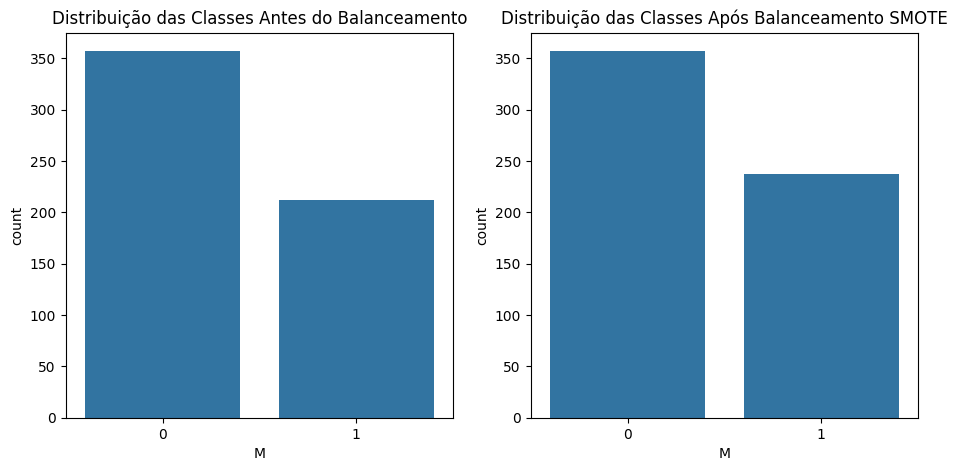

In [44]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(11,5))

ax1.set_title("Distribuição das Classes Antes do Balanceamento")
sns.countplot(x=y,
              ax=ax1)

ax2.set_title("Distribuição das Classes Após Balanceamento SMOTE")
sns.countplot(x=y_balanceado,
              ax=ax2)
plt.show()

---
# Instanciação e Treino do Método k-NN

O método *k-Vizinhos Mais Próximos* (**k-NN**) é um algoritmo de classificação ou regressão supervisionada, baseado na ideia de que uma amostra é classificada de acordo com as classes predominantes entre seus *k vizinhos* mais próximos no espaço das características. Trata-se de um modelo de aprendizado preguiçoso, pois não realiza um treinamento explícito, apenas armazena os dados e realiza os cálculos no momento da predição.

Antes de prosseguir com as etapas de treinamento, é preciso repartir o conjunto eum duas parcelas: uma parcela de **treinamento** e uma parcela para **testes/validação**. Isso é feito utilizando o método `train_test_split` e indicando a reserva de 20% do conjunto para testes.

In [17]:
# 80% para treino + validação cruzada, 20% para teste final
x_treino, x_teste, y_treino, y_teste = train_test_split(
    x_balanceado, y_balanceado, test_size=0.2, random_state=17,stratify=y_balanceado
)

### Preparando validação cruzada

Visando definir os melhores **hiperparâmetros** para o treinamento, foi feita uma análise prévia com a função `cross_validate` buscando avaliar o desempenho do algoritmo k-NN para diferentes quantidades de vizinhos (k).

Para cada valor de k se calcula as medidas de:

- **Acurácia:** quantas vezes o modelo acertou, considerando todos os casos ($n$) separados entre *verdadeiros positivos* ($VP$) e verdadeiros negativos ($VN$).

$$ ac(f_{modelo}) = \frac{VP + VN}{n}$$

- **Precisão:** verifica entre todos os casos que o modelo classificou como *positivos*, incluindo os *falso positivos* ($FP$), quantos de fato são *verdadeiros positivos*.

$$ prec(f_{modelo}) = \frac{VP}{VP + FP}$$

- **Sensibilidade (Recall):** determina entre todos os casos que são *verdadeiros positivos*, incluindo os *falso negativos* ($FN$), quantos o modelo conseguiu identificar corretamente.

$$ sens(f_{modelo}) = \frac{VP}{VP + FN}$$

- **F1-Score:** é a **média harmônica** entre *precisão* e *sensibilidade*, buscando equilíbrio entre os dois.

$$ F1(f_{modelo}) = 2\cdot\frac{prec(f_{modelo}) \times sens(f_{modelo})}{prec(f_{modelo}) + sens(f_{modelo})}$$


Apesar de serem analisadas todas essas medidas, o critério para definir o valor de k será o F1-Score, pois ele representa um equilíbrio entre a **Sensibilidade** e a **Precisão**, que são os parâmetros mais importantes para essa classificação, já que sinalizam a incidência de *falsos positivos* e *falsos negativos*, respectivamente.

In [18]:
def KNN(n_neighbors, x_treino, y_treino):
    modelo = KNeighborsClassifier(n_neighbors=n_neighbors)
    scores = cross_validate(
        modelo,
        x_treino,
        y_treino,
        cv=5,
        scoring=['accuracy', 'precision', 'recall', 'f1'],
        return_train_score=False
    )
    # Calcula a média de cada métrica
    return [
        n_neighbors,
        scores['test_accuracy'].mean(),
        scores['test_precision'].mean(),
        scores['test_recall'].mean(),
        scores['test_f1'].mean()
    ]
def getMelhor(x_treino, y_treino):
  # Executa para k de 1 até 15
  resultados = [KNN(k, x_treino, y_treino) for k in range(1, 16)]

  # Organiza em DataFrame
  df_resultados = pd.DataFrame(resultados, columns=['K', 'Accuracy', 'Precision', 'Recall', 'F1'])

  print("\nResultados gerais:")
  print(df_resultados)

  # Identifica o K com melhor F1-score (ou outra métrica, se quiser)
  melhor = df_resultados.query("F1 == F1.max()")
  print(f"\nMelhor resultado com base no F1-score:")
  print(melhor)
  return df_resultados, melhor
resultado, melhor = getMelhor(x_treino, y_treino)


Resultados gerais:
     K  Accuracy  Precision    Recall        F1
0    1  0.962105   0.963833  0.942105  0.951943
1    2  0.955789   0.983333  0.905263  0.942206
2    3  0.962105   0.963135  0.942105  0.952125
3    4  0.968421   0.984029  0.936842  0.959404
4    5  0.972632   0.973918  0.957895  0.965463
5    6  0.964211   0.977928  0.931579  0.954087
6    7  0.970526   0.978378  0.947368  0.962595
7    8  0.957895   0.977460  0.915789  0.945501
8    9  0.966316   0.978228  0.936842  0.956970
9   10  0.949474   0.977114  0.894737  0.933928
10  11  0.960000   0.972055  0.926316  0.948387
11  12  0.951579   0.977114  0.900000  0.936742
12  13  0.953684   0.977273  0.905263  0.939630
13  14  0.955789   0.988730  0.900000  0.941909
14  15  0.955789   0.983475  0.905263  0.942445

Melhor resultado com base no F1-score:
   K  Accuracy  Precision    Recall        F1
4  5  0.972632   0.973918  0.957895  0.965463


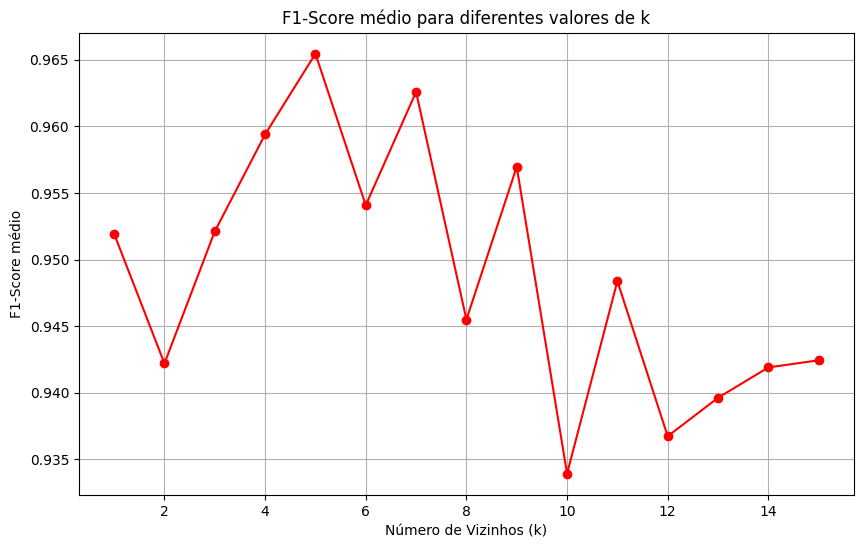

In [19]:
def plotar_dispersão_F1_score(df_resultados):
  plt.figure(figsize=(10,6))

  plt.plot(df_resultados['K'], df_resultados['F1'], marker='o', color='red')

  plt.title('F1-Score médio para diferentes valores de k')
  plt.xlabel('Número de Vizinhos (k)')
  plt.ylabel('F1-Score médio')
  plt.grid(True)
  plt.show()
plotar_dispersão_F1_score(resultado)

Como se pode perceber, e como é esperado, o valor de k que maximiza o F1-Score é um valor ímpar, de modo que se escolhe para o treinamento `k = 5`.

### Treinamento

Definido o valor de k, intancia-se o algoritmo de treinamento, passando o conjunto de treino. Como o k-NN é um algoritmo *preguiçoso*, o "treino" aqui é somente o armazenamento do conjunto de treinamento, que será usado como base para avaliar o conjunto de teste.

In [20]:
modelo = KNeighborsClassifier(n_neighbors=5)

modelo.fit(x_treino,y_treino)

y_predito = modelo.predict(x_teste)

---
# Avaliação do Treinamento

Para avaliar se o modelo está agindo como um bom classificador

Na primeira medida, a **matriz de confusão**, gera-se uma tabela que compara os *valores reais* (`y_teste`) com os *valores previstos* (`y_predito`) pelo modelo. A matriz de confusão permite visualizar de forma clara quantas amostras foram classificadas corretamente e quantas foram classificadas incorretamente, além de onde ele está errando mais.

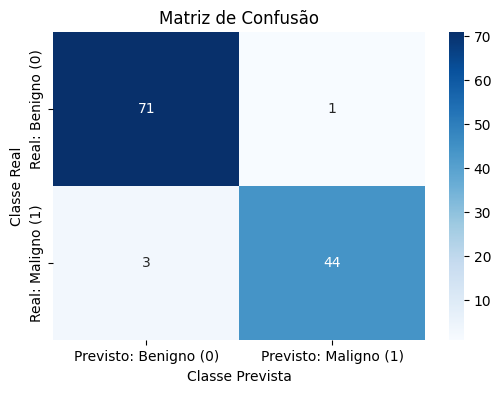

In [21]:
def plotar_matriz_de_confusao(y_teste, y_predito):
  # Calcula a matriz
  matriz = confusion_matrix(y_teste, y_predito, labels=[0, 1])
  # Cria um DataFrame nomeando corretamente
  df_cm = pd.DataFrame(
      matriz,
      index=['Real: Benigno (0)', 'Real: Maligno (1)'],
      columns=['Previsto: Benigno (0)', 'Previsto: Maligno (1)']
  )

  # Plot
  plt.figure(figsize=(6,4))
  sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')

  plt.title('Matriz de Confusão')
  plt.ylabel('Classe Real')
  plt.xlabel('Classe Prevista')
  plt.show()
plotar_matriz_de_confusao(y_teste, y_predito)

Como se está lidando com um problema de classificação binária, a matriz de confusão é do tipo 2x2:

[[VN  FP]

 [FN  VP]]

 onde:
- **VP** (Verdadeiro Positivo) = Malignos corretamente classificados como Malignos
- **FN** (Falso Negativo) = Malignos classificados incorretamente como Benignos.
- **FP** (Falso Positivo) = Benignos classificados incorretamente como Malignos.
- **VN** (Verdadeiro Negativo) = Benignos corretamente classificados como Benignos.

Com base na matriz de confusão, é possível calcular as medidas diretamente:

- **Acurácia:**

$$ ac(f_{modelo}) = \frac{VP + VN}{n} = \frac{44 + 71}{44 + 71 + 3 + 1} = \frac{115}{119} = 0,9664 = 96,64\%$$

- **Precisão:**

$$ prec(f_{modelo}) = \frac{VP}{VP + FP} = \frac{44}{44 + 1} = \frac{44}{45} \approx 0,9778 \approx 97,78\%$$

- **Sensibilidade (Recall):**

$$ sens(f_{modelo}) = \frac{VP}{VP + FN} = \frac{44}{44 + 3} = \frac{44}{47} = 0,9362 = 93,62\%$$

- **F1-Score:**

$$ F1(f_{modelo}) = 2\cdot\frac{prec(f_{modelo}) \times sens(f_{modelo})}{prec(f_{modelo}) + sens(f_{modelo})} = 2\cdot\frac{0,9778 \times 0,9362}{0,9778 + 0,9362} = 0,9565 = 95,65\%$$

As mesmas medidas podem ser extraídas diretamente através do método `classification_report`:

In [22]:
print(classification_report(y_teste, y_predito))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.98      0.94      0.96        47

    accuracy                           0.97       119
   macro avg       0.97      0.96      0.96       119
weighted avg       0.97      0.97      0.97       119



O modelo apresentou um desempenho muito satisfatório, com uma acurácia aproximada de 97%. A precisão e o recall foram elevados para ambas as classes, destacando-se na capacidade de identificar corretamente casos malignos (recall de 94% e precisão de 98%).

Em seguida, realiza-se a plotagem da curva de **Característica de Operação do Receptor**(*Receiver Operating Characteristic* ou **ROC**), que é uma representação gráfica que ilustra o desempenho de um sistema de classificação binária à medida que o seu limiar de discriminação varia.

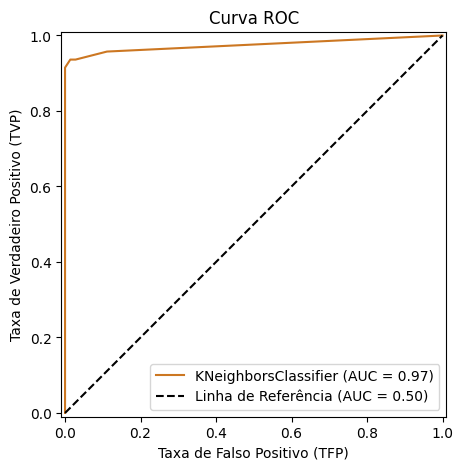

In [23]:
def roc(modelo,x_teste,y_teste):
  fig,ax = plt.subplots(figsize=(11,5))
  RocCurveDisplay.from_estimator(modelo,
                                x_teste,
                                y_teste,
                                curve_kwargs=dict(color="#CC7722"),
                                ax=ax)
  ax.plot([0, 1], [0, 1], 'k--', label='Linha de Referência (AUC = 0.50)')
  ax.set_title("Curva ROC")
  ax.set_xlabel("Taxa de Falso Positivo (TFP)")
  ax.set_ylabel("Taxa de Verdadeiro Positivo (TVP)")
  ax.legend(loc="lower right")

roc(modelo, x_teste, y_teste)

Uma outra abordagem gráfica que se pode verificar, é realizar a plotagem da *fronteira de decisão*, ou seja, o perímetro que divide as duas classes. Como o conjunto foi reduzido para **10 dimensões**, não é possível representar a fronteira final diretamente, logo, opta-se por plotar gráficos bidimensionais com dois componentes PCA de cada vez.

Seguem algumas plotagens:

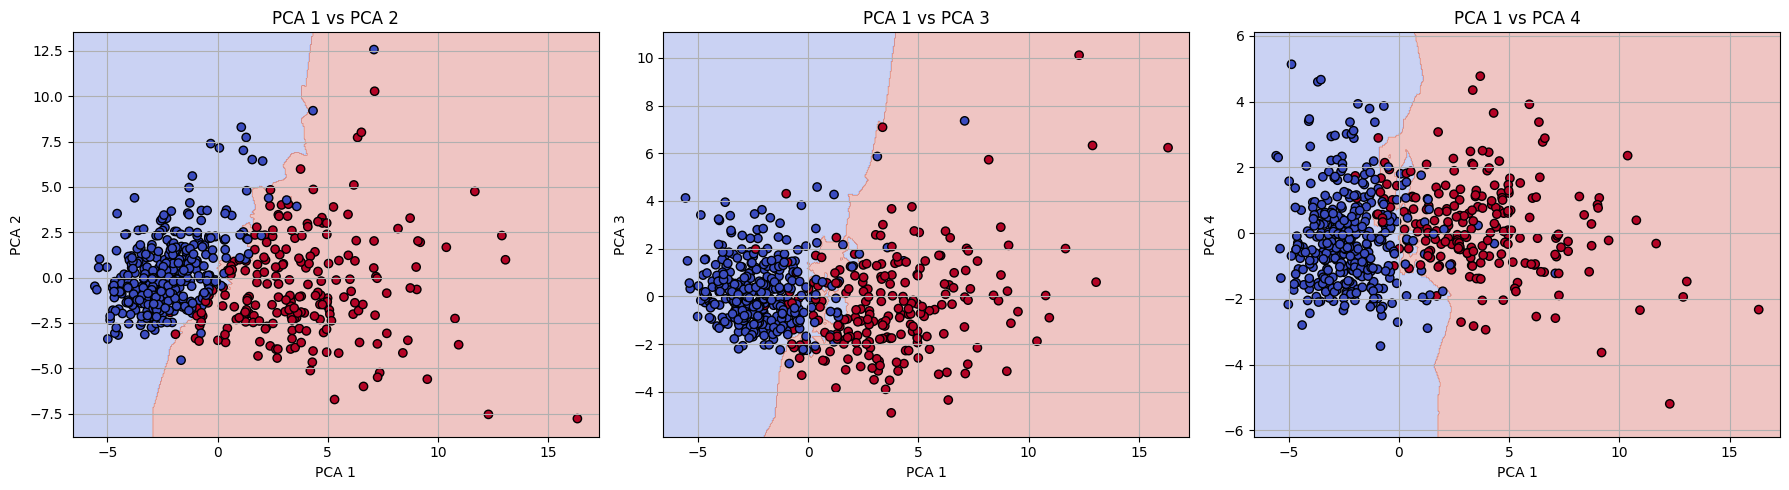

In [45]:
def plot_fronteira_decisao(X, y, atributo1, atributo2, k=5, ax=None):
    """
    Plota a fronteira de decisão considerando dois atributos.

    Parâmetros:
    - X, y: dados
    - atributo1, atributo2: índices das colunas
    - k: número de vizinhos
    - ax: objeto Axes da Matplotlib (para subplot). Se None, cria um novo plot.
    """

    # Suporte para DataFrame ou array
    if hasattr(X, 'iloc'):
        X_par = X.iloc[:, [atributo1, atributo2]].values
    else:
        X_par = X[:, [atributo1, atributo2]]

    y_array = y.values if hasattr(y, 'values') else y

    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_par, y_array)

    x_min, x_max = X_par[:, 0].min() - 1, X_par[:, 0].max() + 1
    y_min, y_max = X_par[:, 1].min() - 1, X_par[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.05),
        np.arange(y_min, y_max, 0.05)
    )

    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Se não tiver eixo (ax), cria um
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,6))

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    scatter = ax.scatter(
        X_par[:, 0], X_par[:, 1],
        c=y_array, cmap=plt.cm.coolwarm, edgecolor='k'
    )

    ax.set_title(f'PCA {atributo1+1} vs PCA {atributo2+1}')
    ax.set_xlabel(f'PCA {atributo1+1}')
    ax.set_ylabel(f'PCA {atributo2+1}')
    ax.grid(True)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))  # 1 linha, 3 colunas

plot_fronteira_decisao(x, y, atributo1=0, atributo2=1, k=5, ax=axs[0])
plot_fronteira_decisao(x, y, atributo1=0, atributo2=2, k=5, ax=axs[1])
plot_fronteira_decisao(x, y, atributo1=0, atributo2=3, k=5, ax=axs[2])

plt.tight_layout()
plt.show()

## Comparação de Desempenho: KNN com e sem PCA

Agora, vamos compara-se o desempenho do algoritmo K-Nearest Neighbors (KNN) utilizando os **dados originais** normalizados (sem a transformação por PCA). O objetivo é avaliar o impacto da redução de dimensionalidade na performance do modelo.

In [25]:
df_treino2 = pd.concat([df_atributos_escalados,dummies.M],axis=1)
x2 = df_treino2.iloc[:,:-1]
y2 = df_treino2.iloc[:,-1]

df_treino2.head(20)

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,M
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015,1
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190,1
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391,1
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010,1
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100,1
5,-0.476375,-0.835335,-0.387148,-0.505650,2.237421,1.244335,0.866302,0.824656,1.005402,1.890005,...,-0.313836,-0.115009,-0.244320,2.048513,1.721616,1.263243,0.905888,1.754069,2.241802,1
6,1.170908,0.160649,1.138125,1.095295,-0.123136,0.088295,0.300072,0.646935,-0.064325,-0.762332,...,0.322883,1.368325,1.275220,0.518640,0.021215,0.509552,1.196716,0.262476,-0.014730,1
7,-0.118517,0.358450,-0.072867,-0.218965,1.604049,1.140102,0.061026,0.281950,1.403355,1.660353,...,0.401048,0.099449,0.028859,1.447961,0.724786,-0.021054,0.624196,0.477640,1.726435,1
8,-0.320167,0.588830,-0.184080,-0.384207,2.201839,1.684010,1.219096,1.150692,1.965600,1.572462,...,0.822813,-0.031609,-0.248363,1.662757,1.818310,1.280035,1.391616,2.389857,1.288650,1
9,-0.473535,1.105439,-0.329482,-0.509063,1.582699,2.563358,1.738872,0.941760,0.797298,2.783096,...,2.443109,-0.286278,-0.297409,2.320295,5.112877,3.995433,1.620015,2.370444,6.846856,1


In [26]:
x2,y2 = balancear(x2,y2)

x_treino2, x_teste2, y_treino2, y_teste2 = train_test_split(
    x2, y2, test_size=0.2, random_state=17,stratify=y2
)

In [27]:
resultado2, melhor2 = getMelhor(x_treino2,y_treino2)


Resultados gerais:
     K  Accuracy  Precision    Recall        F1
0    1  0.964211   0.967901  0.942105  0.954205
1    2  0.951579   0.988235  0.889474  0.935899
2    3  0.964211   0.963548  0.947368  0.955002
3    4  0.957895   0.977460  0.915789  0.945501
4    5  0.970526   0.978513  0.947368  0.962591
5    6  0.964211   0.983333  0.926316  0.953943
6    7  0.968421   0.978228  0.942105  0.959784
7    8  0.960000   0.977778  0.921053  0.948384
8    9  0.966316   0.973257  0.942105  0.957255
9   10  0.951579   0.977414  0.900000  0.936733
10  11  0.957895   0.972346  0.921053  0.945784
11  12  0.949474   0.977114  0.894737  0.933928
12  13  0.953684   0.971905  0.910526  0.940170
13  14  0.951579   0.988571  0.889474  0.936130
14  15  0.951579   0.988571  0.889474  0.936130

Melhor resultado com base no F1-score:
   K  Accuracy  Precision    Recall        F1
4  5  0.970526   0.978513  0.947368  0.962591


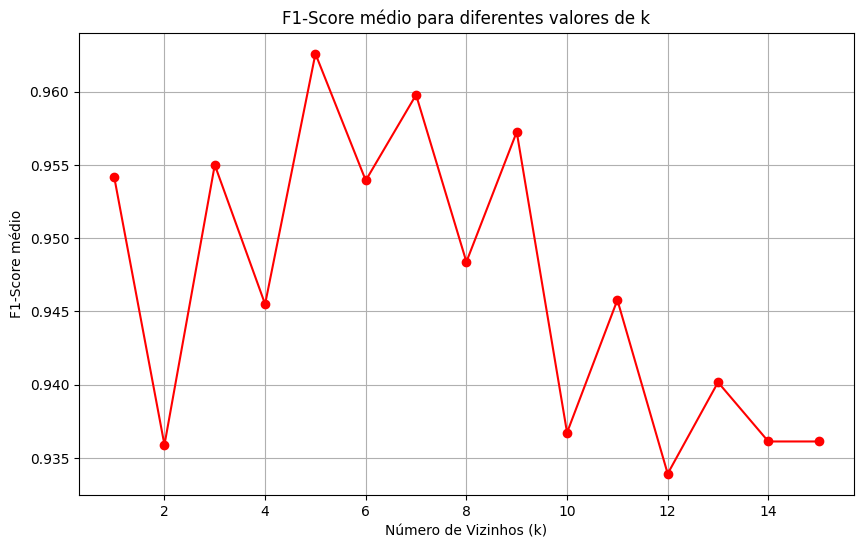

In [28]:
plotar_dispersão_F1_score(resultado2)


### Impacto do PCA na Performance do KNN



In [29]:
print(f"Diferença:\nAcurárcia: {melhor.Accuracy.iloc[0] - melhor2.Accuracy.iloc[0]}\n"
      f"Precisão: {melhor.Precision.iloc[0] - melhor2.Precision.iloc[0]}\n"
      f"Revocação: {melhor.Recall.iloc[0] - melhor2.Recall.iloc[0]}\n"
      f"F1: {melhor.F1.iloc[0] - melhor2.F1.iloc[0]}\n")

Diferença:
Acurárcia: 0.002105263157894832
Precisão: -0.004594594594594548
Revocação: 0.010526315789473828
F1: 0.002871794871794675



### A diferença entre o **score obtido após a aplicação do PCA** e o **score de desempenho atual** (sem PCA) foi praticamente nula.

Isso sugere que, a redução de dimensionalidade via PCA **não resultou em uma melhora ou piora perceptível** nas medidas de avaliação escolhidas para este dataset e modelo KNN utilizados.

O que também pode ser observado na matriz de confusão e na Curva ROC:

In [30]:
modelo = KNeighborsClassifier(n_neighbors=5)

modelo.fit(x_treino2,y_treino2)

y_predito2 = modelo.predict(x_teste2)

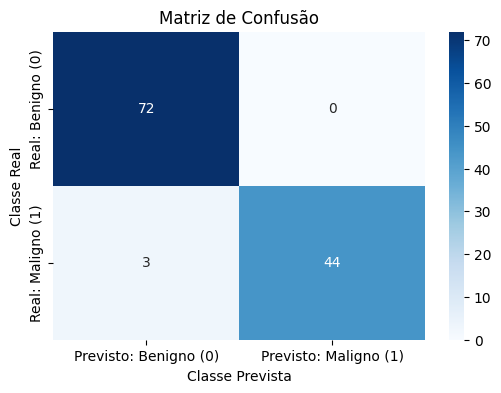

In [31]:
plotar_matriz_de_confusao(y_teste2,y_predito2)

In [32]:
print(classification_report(y_teste2, y_predito2))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.94      0.97        47

    accuracy                           0.97       119
   macro avg       0.98      0.97      0.97       119
weighted avg       0.98      0.97      0.97       119



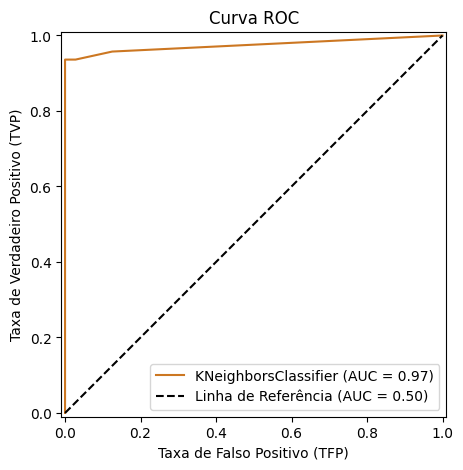

In [33]:
roc(modelo, x_teste2,y_teste2)

### Comparação de Desempenho com Atributos Selecionados

Os Pesquisadores da universidade de Wisconsin notaram que o **desempenho ideal do classificador** dependia da **seleção cuidadosa de atributos** para a separação dos dados. A combinação de atributos que resultou no melhor desempenho possuía um **significado distinto** para cada um. A melhor combinação encontrada envolvia um atributo relacionado ao **tamanho** e outro ao **formato**.


Agora, será observado o desempenho da classificação utilizando o conjunto de três atributos que se mostraram mais promissores no estudo desenvolvido pelos pesquisadores: **a Média da Textura, os Valores Extremos da Área e da Suavidade**.

In [34]:
#Pedaços
#t   - texture
#a   - area
#s   - smoothness

t1_a3_s3 = pd.DataFrame([df_atributos_escalados.texture1, df_atributos_escalados.area3, df_atributos_escalados.smoothness3,dummies.M]).T
t1_a3_s3.columns = ["texturaMedia","areaValoresExtremos","suavidadeValoresExtremos","M"]
t1_a3_s3.head(5)

,texturaMedia,areaValoresExtremos,suavidadeValoresExtremos,M
0,-2.073335,2.001237,1.307686,1.0
1,-0.353632,1.890489,-0.375612,1.0
2,0.456187,1.456285,0.527407,1.0
3,0.253732,-0.550021,3.394275,1.0
4,-1.151816,1.220724,0.220556,1.0


In [35]:
x3 = t1_a3_s3.iloc[:,:-1]
y3 = t1_a3_s3.iloc[:,-1]

In [36]:
x3, y3 = balancear(x3, y3)


x_treino3,x_teste3,y_treino3,y_teste3 = train_test_split(x3,y3,random_state=14,test_size=0.2,stratify=y3)


In [37]:
resultado3, melhor3 = getMelhor(x_treino3,y_treino3)


Resultados gerais:
     K  Accuracy  Precision    Recall        F1
0    1  0.945263   0.940367  0.921053  0.930517
1    2  0.938947   0.976292  0.868421  0.919089
2    3  0.951579   0.957259  0.921053  0.938062
3    4  0.936842   0.959777  0.878947  0.917177
4    5  0.941053   0.950330  0.900000  0.924073
5    6  0.941053   0.976034  0.873684  0.921407
6    7  0.951579   0.971186  0.905263  0.936576
7    8  0.945263   0.971035  0.889474  0.928059
8    9  0.947368   0.971035  0.894737  0.930951
9   10  0.941053   0.970885  0.878947  0.922275
10  11  0.947368   0.971053  0.894737  0.931108
11  12  0.945263   0.982134  0.878947  0.927283
12  13  0.947368   0.976757  0.889474  0.930635
13  14  0.943158   0.982312  0.873684  0.924303
14  15  0.947368   0.982480  0.884211  0.930330

Melhor resultado com base no F1-score:
   K  Accuracy  Precision    Recall        F1
2  3  0.951579   0.957259  0.921053  0.938062


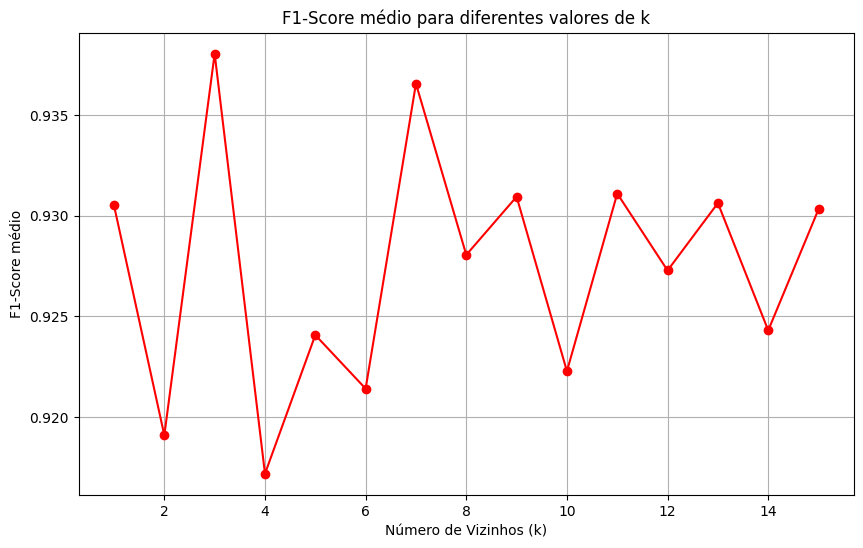

In [38]:
plotar_dispersão_F1_score(resultado3)

### Impacto da seleção de atributos na Performance do KNN

In [39]:
print(f"Diferença:\nAcurárcia: {melhor.Accuracy.iloc[0] - melhor3.Accuracy.iloc[0]}\n"
      f"Precisão: {melhor.Precision.iloc[0] - melhor3.Precision.iloc[0]}\n"
      f"Revocação: {melhor.Recall.iloc[0] - melhor3.Recall.iloc[0]}\n"
      f"F1: {melhor.F1.iloc[0] - melhor3.F1.iloc[0]}\n")

Diferença:
Acurárcia: 0.021052631578947434
Precisão: 0.016659441396283503
Revocação: 0.0368421052631579
F1: 0.02740054257574065



### A diferença entre o **score obtido após a aplicação do PCA** e o **score de desempenho atual** (atributos selecionados) apresentou valores na ordem da segunda casa decimal.

Isso indica que, a seleção de atributos segundo **as medidas de avaliação escolhidas** não apresentou uma mudança significativa de desempenho em relação à redução de dimensionalidade via PCA.

O que também pode ser observado na matriz de confusão e na Curva ROC:

In [40]:
modelo = KNeighborsClassifier(n_neighbors=3)

modelo.fit(x_treino3,y_treino3)

y_predito3 = modelo.predict(x_teste3)

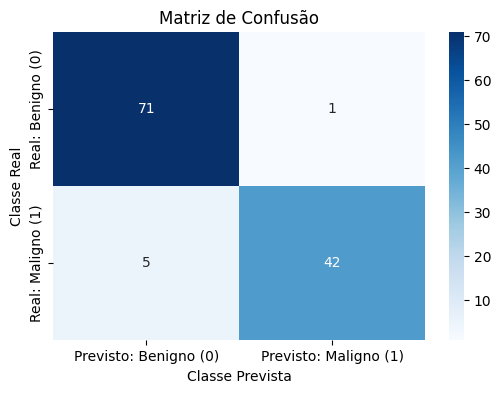

In [41]:
plotar_matriz_de_confusao(y_teste3, y_predito3)

In [42]:
print(classification_report(y_teste3, y_predito3))

              precision    recall  f1-score   support

         0.0       0.93      0.99      0.96        72
         1.0       0.98      0.89      0.93        47

    accuracy                           0.95       119
   macro avg       0.96      0.94      0.95       119
weighted avg       0.95      0.95      0.95       119



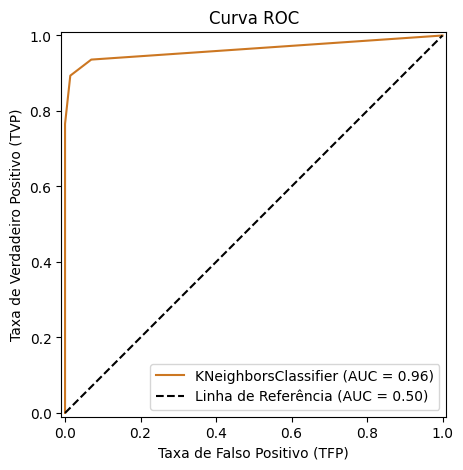

In [43]:
roc(modelo, x_teste3, y_teste3)

## Referências Bibliográficas

[1] STREET, W; WOLBERG, W; MANGASARIAN, O. **Nuclear feature extraction for breast tumor diagnosis.** 1993. Published in Electronic imaging. Disponível em: https://www.semanticscholar.org/paper/Nuclear-feature-extraction-for-breast-tumor-Street-Wolberg/53f0fbb425bc14468eb3bf96b2e1d41ba8087f36 Acesso em 18 de abril de 2024.